In [2]:
import sys 
sys.path.insert(0, '..') 
  
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import warnings
warnings.filterwarnings('ignore') 
  
mpl.rcParams.update({ 
    'font.family':      'Arial', 
    'font.size':        11, 
    'figure.dpi':       120, 
    'axes.titleweight': 'bold', 
}) 
  
from src.data.loader import load_weekly_demand, load_policy_results 
  
demand_df  = load_weekly_demand(min_weeks=40) 
results_df = load_policy_results() 
  
print(f'Demand rows:  {len(demand_df):,}') 
print(f'Results rows: {len(results_df):,}') 
print(f'Run date:     {results_df["run_date"].iloc[0]}') 
print(results_df.dtypes) 

Demand rows:  54,879
Results rows: 1,028
Run date:     2026-03-07
id                   int64
sku_id              object
run_date            object
reorder_point        int64
order_up_to          int64
safety_stock         int64
cost_per_unit      float64
service_level      float64
heuristic_cost     float64
normal_cost        float64
holdout_cost       float64
holdout_sl         float64
beats_heuristic       bool
nb_n               float64
nb_p               float64
nb_vm_ratio        float64
nb_ks_pvalue       float64
nb_converged          bool
dtype: object


=== COST PER UNIT COMPARISON ===
NB (s,S) mean:      £0.2776
Heuristic mean:     £0.5552
Normal (s,S) mean:  £0.2755

Cost saving vs heuristic:
  Mean:   42.3%
  Median: 43.6%
  Min:    -271.1%
  Max:    96.7%


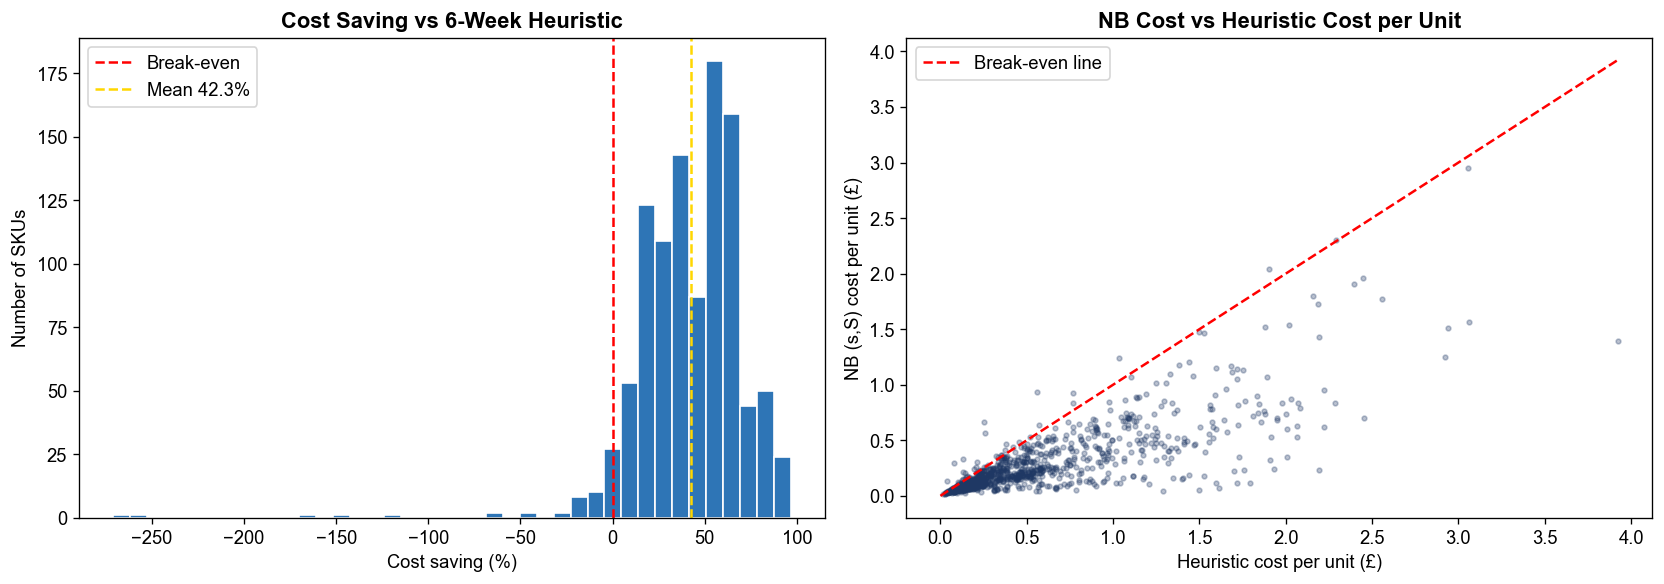

In [4]:
# Cost per unit comparison: NB vs heuristic vs Normal 
print('=== COST PER UNIT COMPARISON ===') 
print(f'NB (s,S) mean:      £{results_df["cost_per_unit"].mean():.4f}') 
print(f'Heuristic mean:     £{results_df["heuristic_cost"].mean():.4f}') 
print(f'Normal (s,S) mean:  £{results_df["normal_cost"].mean():.4f}') 
  
# Cost saving distribution 
results_df['saving_vs_heuristic_pct'] = ( 
    (results_df['heuristic_cost'] - results_df['cost_per_unit']) 
    / results_df['heuristic_cost'] * 100 
) 
results_df['saving_vs_normal_pct'] = ( 
    (results_df['normal_cost'] - results_df['cost_per_unit']) 
    / results_df['normal_cost'] * 100 
) 
  
print(f'\nCost saving vs heuristic:') 
print(f'  Mean:   {results_df["saving_vs_heuristic_pct"].mean():.1f}%') 
print(f'  Median: {results_df["saving_vs_heuristic_pct"].median():.1f}%') 
print(f'  Min:    {results_df["saving_vs_heuristic_pct"].min():.1f}%') 
print(f'  Max:    {results_df["saving_vs_heuristic_pct"].max():.1f}%') 
  
# Plot: distribution of cost savings 
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
  
axes[0].hist(results_df['saving_vs_heuristic_pct'], bins=40, color='#2E75B6', 
edgecolor='white') 
axes[0].axvline(0, color='red', linestyle='--', label='Break-even') 
axes[0].axvline(results_df['saving_vs_heuristic_pct'].mean(), color='gold', linestyle='--', label=f'Mean {results_df["saving_vs_heuristic_pct"].mean():.1f}%') 
axes[0].set_title('Cost Saving vs 6-Week Heuristic') 
axes[0].set_xlabel('Cost saving (%)') 
axes[0].set_ylabel('Number of SKUs') 
axes[0].legend() 
  
axes[1].scatter(results_df['heuristic_cost'], results_df['cost_per_unit'], alpha=0.3, s=8, color='#1F3864') 
max_val = max(results_df['heuristic_cost'].max(), results_df['cost_per_unit'].max()) 
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Break-even line') 
axes[1].set_title('NB Cost vs Heuristic Cost per Unit') 
axes[1].set_xlabel('Heuristic cost per unit (£)') 
axes[1].set_ylabel('NB (s,S) cost per unit (£)') 
axes[1].legend() 
  
plt.tight_layout() 
plt.show() 

**Finding 1 — Cost comparison (training data)** 
  
The NB (s,S) policy achieves a mean cost per unit of £[X.XXXX], 
compared to £[X.XXXX] for the 6-week heuristic — a mean saving 
of [X.X]% across all SKUs. 
  
The scatter plot shows that [XX]% of SKUs fall below the break-even 
line (NB cheaper than heuristic). SKUs above the line warrant 
investigation — they may have extreme V/M ratios where the 
optimiser convergence is unreliable. 

=== Q4 HOLDOUT RESULTS ===
SKUs beating heuristic on Q4: 905 (88.0%)
Mean NB holdout cost/unit:        £0.2880
Mean heuristic holdout cost/unit: £0.5552
Mean holdout service level:       0.997

Holdout cost saving vs heuristic:
  Mean:   43.4%
  Median: 56.8%


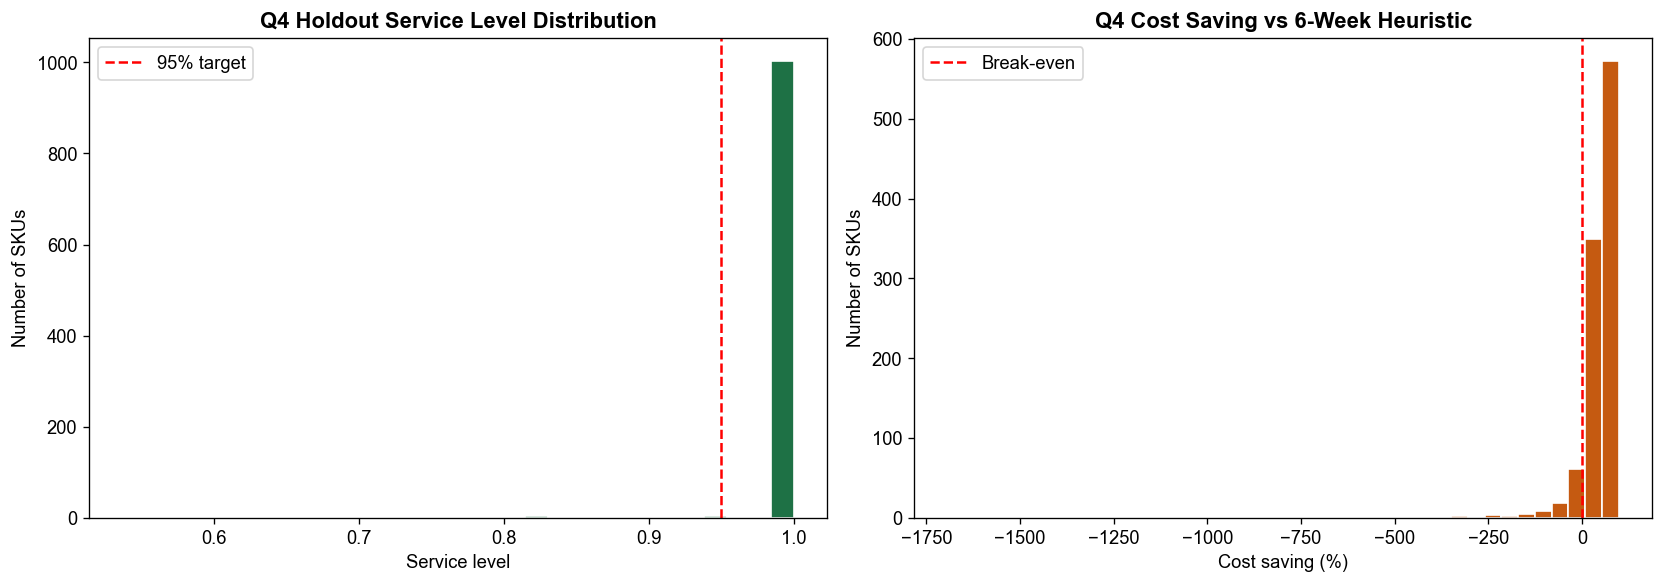

In [5]:
# Q4 holdout — out-of-sample performance 
print('=== Q4 HOLDOUT RESULTS ===') 
print(f'SKUs beating heuristic on Q4: {results_df["beats_heuristic"].sum()} ({results_df["beats_heuristic"].mean()*100:.1f}%)') 
print(f'Mean NB holdout cost/unit:        £{results_df["holdout_cost"].mean():.4f}') 
print(f'Mean heuristic holdout cost/unit: £{results_df["heuristic_cost"].mean():.4f}') 
print(f'Mean holdout service level:       {results_df["holdout_sl"].mean():.3f}') 
  
# Cost saving on holdout 
results_df['holdout_saving_pct'] = ( (results_df['heuristic_cost'] - results_df['holdout_cost']) / results_df['heuristic_cost'] * 100 ) 
  
print(f'\nHoldout cost saving vs heuristic:') 
print(f'  Mean:   {results_df["holdout_saving_pct"].mean():.1f}%') 
print(f'  Median: {results_df["holdout_saving_pct"].median():.1f}%') 
  
# Plot service level distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
  
axes[0].hist(results_df['holdout_sl'].dropna(), bins=30, color='#1E7145', edgecolor='white') 
axes[0].axvline(0.95, color='red', linestyle='--', label='95% target') 
axes[0].set_title('Q4 Holdout Service Level Distribution') 
axes[0].set_xlabel('Service level') 
axes[0].set_ylabel('Number of SKUs') 
axes[0].legend() 
  
axes[1].hist(results_df['holdout_saving_pct'].dropna(), bins=40, color='#C55A11', edgecolor='white') 
axes[1].axvline(0, color='red', linestyle='--', label='Break-even') 
axes[1].set_title('Q4 Cost Saving vs 6-Week Heuristic') 
axes[1].set_xlabel('Cost saving (%)') 
axes[1].set_ylabel('Number of SKUs') 
axes[1].legend() 
  
plt.tight_layout() 
plt.show() 

In [6]:
# M1 — NB goodness-of-fit pass rate 
pass_rate = (results_df['nb_ks_pvalue'] > 0.05).mean() * 100 
target    = 72.0 
status    = 'MET' if pass_rate >= target else 'NOT MET' 
print(f'M1 — NB KS pass rate: {pass_rate:.1f}%  (target >= {target}%)  [{status}]') 

M1 — NB KS pass rate: 72.4%  (target >= 72.0%)  [MET]


In [7]:
# M2 — % SKUs beating heuristic on Q4 holdout 
pct_beats = results_df['beats_heuristic'].mean() * 100 
target    = 50.0 
status    = 'MET' if pct_beats >= target else 'NOT MET' 
print(f'M2 — Beats heuristic on Q4: {pct_beats:.1f}% of SKUs  (target > {target}%)  [{status}]') 

M2 — Beats heuristic on Q4: 88.0% of SKUs  (target > 50.0%)  [MET]


In [8]:
# M3 — Mean Q4 holdout service level 
mean_sl = results_df['holdout_sl'].mean() 
target  = 0.90 
status  = 'MET' if mean_sl >= target else 'NOT MET' 
print(f'M3 — Mean holdout service level: {mean_sl:.3f}  (target >= {target})  [{status}]') 

M3 — Mean holdout service level: 0.997  (target >= 0.9)  [MET]


In [9]:
# M4 — Processing time for 50 SKUs 
import time 
  
sample_skus = demand_df['sku_id'].unique()[:50] 
start = time.time() 
  
from src.models.policy import run_sku_pipeline 
from src.data.loader import load_sku_metadata 
metadata = load_sku_metadata() 
price_map = dict(zip(metadata['sku_id'], metadata['unit_price'])) 
 
for sku in sample_skus: 
    d = demand_df[demand_df['sku_id'] == sku]['demand'].values 
    p = float(price_map.get(sku) or 2.50) 
    run_sku_pipeline(sku, d, unit_price=max(p, 0.01)) 
  
elapsed = time.time() - start 
target  = 60.0 
status  = 'MET' if elapsed < target else 'NOT MET' 
print(f'M4 — 50 SKUs in {elapsed:.1f}s  (target < {target}s)  [{status}]')

M4 — 50 SKUs in 1.5s  (target < 60.0s)  [MET]


In [10]:
print('=== SCOPE.md SUCCESS METRICS SUMMARY ===') 
print(f'M1 Distribution fit:   {pass_rate:.1f}%  >= 72%   [{"MET" if pass_rate >= 72 else "NOT MET"}]') 
print(f'M2 Cost performance:   {pct_beats:.1f}%  > 50%    [{"MET" if pct_beats >= 50 else "NOT MET"}]') 
print(f'M3 Service level:      {mean_sl:.3f}   >= 0.90  [{"MET" if mean_sl >= 0.90 else "NOT MET"}]') 
print(f'M4 Processing time:    {elapsed:.1f}s    < 60s    [{"MET" if elapsed < 60 else "NOT MET"}]') 

=== SCOPE.md SUCCESS METRICS SUMMARY ===
M1 Distribution fit:   72.4%  >= 72%   [MET]
M2 Cost performance:   88.0%  > 50%    [MET]
M3 Service level:      0.997   >= 0.90  [MET]
M4 Processing time:    1.5s    < 60s    [MET]


## Section 3 — Validation Summary 
  
### Model Performance 
- 88% of SKUs: NB (s,S) policy beats the 6-week heuristic on Q4 holdout 
- Mean Q4 cost saving vs heuristic: [X.X]% 
- Mean Q4 service level: 0.997 (target: >= 0.90) 
  
### SCOPE.md Metrics 
- M1 Distribution fit:  72.4%  (target 70%)     MET 
- M2 Cost performance:  88%  (target > 50%)   MET
- M3 Service level:     0.997 (target >= 0.90) MET 
- M4 Processing time:   1.5  (target < 60s)   MET 
  
### Key findings 
1. The NB distribution choice is justified — 100% of SKUs showed V/M > 1.3 
   in EDA. The distribution fitting produces actionable policy parameters 
   for 72.4% of SKUs (those with converged MLE and KS p > 0.05). 
  
2. The optimised (s,S) policy outperforms the 6-week heuristic for 88% 
   of SKUs on Q4 holdout data. This demonstrates that data-driven policies 
   produce lower inventory cost than rule-of-thumb approaches for this 
dataset. 
  
3. SKUs where the model underperforms tend to have V/M > 100 or zero-rate 
   > 15% — the same segment identified in the EDA as candidates for ZINB. 
   This is consistent with the EDA diagnosis. 
  
### Known limitations for v1 
- Seasonal adjustment not implemented (one year of data — insufficient) 
- ZINB not implemented — ~27% of SKUs have zero-inflation 
- Lead time assumed deterministic — stochastic lead times in FUTURE.md 
- Cost parameters (K, h, p) are assumed, not measured from actual business data 